In [1]:
import os
import re
import json
import string
import random
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import clone_model
from tensorflow.keras.applications import EfficientNetV2B0
from sklearn.metrics import accuracy_score, classification_report
from transformers import AutoModel, TFAutoModel, AutoTokenizer, BertTokenizer
from PIL import Image
import pandas as pd
from sklearn.model_selection import train_test_split

2025-08-16 15:07:24.212648: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
with tf.device("/cpu:0"):
    dataset = tf.data.Dataset.load(
        "dataset384",
        element_spec=({
            'title': tf.TensorSpec(shape=(None, 32), dtype=tf.int32),
            'content': tf.TensorSpec(shape=(None, 128), dtype=tf.int32),
            'titlemask': tf.TensorSpec(shape=(None, 32), dtype=tf.int32),
            'contentmask': tf.TensorSpec(shape=(None, 128), dtype=tf.int32),
            'image': tf.TensorSpec(shape=(None, 384, 384, 3), dtype=tf.uint8)
        }, tf.TensorSpec(shape=(None, ), dtype=tf.int32))
    )
    
    dataVal = tf.data.Dataset.load(
        "dataVal384",
        element_spec=({
            'title': tf.TensorSpec(shape=(None, 32), dtype=tf.int32),
            'content': tf.TensorSpec(shape=(None, 128), dtype=tf.int32),
            'titlemask': tf.TensorSpec(shape=(None, 32), dtype=tf.int32),
            'contentmask': tf.TensorSpec(shape=(None, 128), dtype=tf.int32),
            'image': tf.TensorSpec(shape=(None, 384, 384, 3), dtype=tf.uint8)
        }, tf.TensorSpec(shape=(None, ), dtype=tf.int32))
    )

2025-08-16 15:07:26.762147: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:05:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-08-16 15:07:26.774729: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:05:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-08-16 15:07:26.774791: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:05:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-08-16 15:07:26.776755: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:05:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-08-16 15:07:26.776797: I external/local_xla/xla/stream_executor

In [3]:
with tf.device("/cpu:0"):
    class BertEmbeddingLayer(tf.keras.layers.Layer):
        def __init__(self, model_name, **kwargs):
            super(BertEmbeddingLayer, self).__init__(**kwargs)
            self.model_name = model_name
            self.embedding_size = None
            self.bert = None
    
        def build(self, input_shape):
            # Load the model during build phase
            self.bert = TFAutoModel.from_pretrained(self.model_name)
            self.embedding_size = self.bert.config.hidden_size
            # This makes sure the layer is marked as built
            super(BertEmbeddingLayer, self).build(input_shape)
    
        def call(self, inputs):
            ids, att = inputs
            outputs = self.bert(input_ids=ids, attention_mask=att)
            return outputs.pooler_output
    
        def get_config(self):
            config = super(BertEmbeddingLayer, self).get_config()
            config.update({"model_name": self.model_name})
            return config

In [4]:
with tf.device("/cpu:0"):
    def makemodel(output_bias=None):
        # Text using IndoBertp1
        ids1 = tf.keras.layers.Input(shape=(32,), dtype=tf.int32, name="title")
        att1 = tf.keras.layers.Input(shape=(32,), dtype=tf.int32, name="titlemask")
        ids2 = tf.keras.layers.Input(shape=(128,), dtype=tf.int32, name="content")
        att2 = tf.keras.layers.Input(shape=(128,), dtype=tf.int32, name="contentmask")
    
        indobert1 = BertEmbeddingLayer(model_name="indobenchmark/indobert-base-p1", name="indobert1")
        indobert2 = BertEmbeddingLayer(model_name="indobenchmark/indobert-base-p1", name="indobert2")
    
        title = indobert1([ids1, att1])
        content = indobert2([ids2, att2])
    
        # Image using EfficientNetV2
        img1 = tf.keras.layers.Input(shape=(384,384,3), dtype=tf.uint8, name="image")
    
        effi = EfficientNetV2B0(
            include_top = False,
            weights = 'imagenet',
            input_shape = (384,384,3),
            pooling = 'max'
        )
        image = effi(img1)
    
        fin = tf.keras.layers.concatenate([title, content, image])
        fin = tf.keras.layers.BatchNormalization()(fin)
            
        fin = tf.keras.layers.Dense(512, activation=None)(fin)
        fin = tf.keras.layers.BatchNormalization()(fin)
        fin = tf.keras.layers.Activation('relu')(fin)
        fin = tf.keras.layers.Dropout(0.4)(fin) 
    
        fin = tf.keras.layers.Dense(256, activation=None)(fin)
        fin = tf.keras.layers.BatchNormalization()(fin)
        fin = tf.keras.layers.Activation('relu')(fin)
        fin = tf.keras.layers.Dropout(0.4)(fin) 
        
        fin = tf.keras.layers.Dense(128, activation=None)(fin)
        fin = tf.keras.layers.BatchNormalization()(fin)
        fin = tf.keras.layers.Activation('relu')(fin)
        fin = tf.keras.layers.Dropout(0.4)(fin) 
        
        fin = tf.keras.layers.Dense(64, activation='relu')(fin)
        fin = tf.keras.layers.Dropout(0.2)(fin)
        fin = tf.keras.layers.Dense(1, activation='sigmoid')(fin)
    
        final = tf.keras.Model(inputs=[ids1, att1, ids2, att2, img1], outputs=fin)
    
        for layer in final.layers:
          layer.trainable = True
        optimizer = tf.keras.optimizers.Adam(learning_rate = 0.00005)
        final.compile(
            loss = tf.keras.losses.BinaryCrossentropy(),
            optimizer=optimizer,
            metrics=[tf.keras.metrics.BinaryAccuracy(),tf.keras.metrics.Precision(),tf.keras.metrics.Recall()]
        )
    
        return final
    
    final = makemodel()
    final.summary()

Some layers from the model checkpoint at indobenchmark/indobert-base-p1 were not used when initializing TFBertModel: ['nsp___cls', 'mlm___cls', 'bert/encoder/layer_._5/output/LayerNorm/gamma:0', 'bert/encoder/layer_._6/output/LayerNorm/beta:0', 'bert/encoder/layer_._6/attention/self/query/kernel:0', 'bert/encoder/layer_._1/attention/self/value/bias:0', 'bert/encoder/layer_._7/attention/output/LayerNorm/beta:0', 'bert/encoder/layer_._3/attention/output/LayerNorm/beta:0', 'bert/encoder/layer_._1/output/dense/bias:0', 'bert/encoder/layer_._9/attention/output/LayerNorm/beta:0', 'bert/encoder/layer_._3/attention/self/value/bias:0', 'bert/encoder/layer_._11/attention/self/query/kernel:0', 'bert/encoder/layer_._7/attention/self/value/bias:0', 'bert/encoder/layer_._8/attention/output/LayerNorm/beta:0', 'bert/encoder/layer_._4/intermediate/dense/bias:0', 'bert/encoder/layer_._7/attention/self/key/kernel:0', 'bert/encoder/layer_._4/attention/self/value/kernel:0', 'bert/encoder/layer_._6/output/d

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ title (InputLayer)  │ (None, 32)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ titlemask           │ (None, 32)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ content             │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ contentmask         │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image (InputLayer)  │ (None, 384, 384,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ indobert1           │ (None, 768)       │          0 │ title[0][0],      │
│ (BertEmbeddingLaye… │                   │            │ titlemask[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ indobert2           │ (None, 768)       │          0 │ content[0][0],    │
│ (BertEmbeddingLaye… │                   │            │ contentmask[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetv2-b0   │ (None, 1280)      │  5,919,312 │ image[0][0]       │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2816)      │          0 │ indobert1[0][0],  │
│ (Concatenate)       │                   │            │ indobert2[0][0],  │
│                     │                   │            │ efficientnetv2-b… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2816)      │     11,264 │ concatenate[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  1,442,304 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 512)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ activation_1[0][

 Total params: 7,549,009 (28.80 MB)

 Trainable params: 7,480,977 (28.54 MB)

 Non-trainable params: 68,032 (265.75 KB)

In [5]:
tf.keras.mixed_precision.set_global_policy('mixed_float16')
with tf.device("/cpu:0"):
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
        )
    
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=1,
        min_lr=1e-8
    )
    
    history=final.fit(x = dataset,
                      epochs = 15,
                      callbacks=[early_stopping, reduce_lr],
                      validation_data=dataVal
                      )

Epoch 1/15


I0000 00:00:1755331714.984565    5300 service.cc:145] XLA service 0x7951440359b0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1755331714.984610    5300 service.cc:153]   StreamExecutor device (0): Host, Default Version
2025-08-16 15:08:36.484747: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
W0000 00:00:1755331717.498710    5300 assert_op.cc:38] Ignoring Assert operator functional_1/indobert1_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert
W0000 00:00:1755331717.617908    5300 assert_op.cc:38] Ignoring Assert operator functional_1/indobert2_1/tf_bert_model_1/bert/embeddings/assert_less/Assert/Assert
I0000 00:00:1755331789.006068    5300 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2025-08-16 15:09:49.041885: W external/local_tsl/tsl/framewor

  1/350 ━━━━━━━━━━━━━━━━━━━━ 13:12:50 136s/step - binary_accuracy: 0.3750 - loss: 0.8986 - precision: 0.3000 - recall: 0.5000

2025-08-16 15:10:06.460352: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 5282191072 exceeds 10% of free system memory.


  2/350 ━━━━━━━━━━━━━━━━━━━━ 1:46:25 18s/step - binary_accuracy: 0.4297 - loss: 0.8626 - precision: 0.3474 - recall: 0.5500  

...

349/350 ━━━━━━━━━━━━━━━━━━━━ 17s 18s/step - binary_accuracy: 0.5251 - loss: 0.7533 - precision: 0.4600 - recall: 0.5248

W0000 00:00:1755338030.349062    5300 assert_op.cc:38] Ignoring Assert operator functional_1/indobert1_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert
W0000 00:00:1755338030.355166    5300 assert_op.cc:38] Ignoring Assert operator functional_1/indobert2_1/tf_bert_model_1/bert/embeddings/assert_less/Assert/Assert


350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 18s/step - binary_accuracy: 0.5251 - loss: 0.7533 - precision: 0.4601 - recall: 0.5247 

W0000 00:00:1755338108.293897    5297 assert_op.cc:38] Ignoring Assert operator functional_1/indobert1_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert
W0000 00:00:1755338108.398562    5297 assert_op.cc:38] Ignoring Assert operator functional_1/indobert2_1/tf_bert_model_1/bert/embeddings/assert_less/Assert/Assert
W0000 00:00:1755338655.843364    5300 assert_op.cc:38] Ignoring Assert operator functional_1/indobert1_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert
W0000 00:00:1755338655.849184    5300 assert_op.cc:38] Ignoring Assert operator functional_1/indobert2_1/tf_bert_model_1/bert/embeddings/assert_less/Assert/Assert


350/350 ━━━━━━━━━━━━━━━━━━━━ 6995s 20s/step - binary_accuracy: 0.5252 - loss: 0.7532 - precision: 0.4602 - recall: 0.5246 - val_binary_accuracy: 0.6385 - val_loss: 0.6501 - val_precision: 0.6161 - val_recall: 0.3995 - learning_rate: 5.0000e-05
Epoch 2/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 6733s 19s/step - binary_accuracy: 0.5957 - loss: 0.6827 - precision: 0.5392 - recall: 0.4627 - val_binary_accuracy: 0.6657 - val_loss: 0.6059 - val_precision: 0.6289 - val_recall: 0.5231 - learning_rate: 5.0000e-05
Epoch 3/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 6712s 19s/step - binary_accuracy: 0.6443 - loss: 0.6323 - precision: 0.6046 - recall: 0.5178 - val_binary_accuracy: 0.6979 - val_loss: 0.5788 - val_precision: 0.6641 - val_recall: 0.5870 - learning_rate: 5.0000e-05
Epoch 4/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 6721s 19s/step - binary_accuracy: 0.6662 - loss: 0.6160 - precision: 0.6348 - recall: 0.5414 - val_binary_accuracy: 0.7126 - val_loss: 0.5613 - val_precision: 0.6780 - val_recall: 0.6182 - learning_rate: 5.

In [6]:
with tf.device("/cpu:0"):
    y_pred = final.predict(dataVal)
    y_pred_binary = (y_pred > 0.5).astype(int)
    from sklearn.metrics import classification_report
    y_val = np.concatenate([y for _, y in dataVal.as_numpy_iterator()])
    print(classification_report(y_val, y_pred_binary, 
                               target_names=['Class_0', 'Class_1'],
                               digits = 4))

W0000 00:00:1755419618.602982    5300 assert_op.cc:38] Ignoring Assert operator functional_1/indobert1_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert
W0000 00:00:1755419618.648027    5300 assert_op.cc:38] Ignoring Assert operator functional_1/indobert2_1/tf_bert_model_1/bert/embeddings/assert_less/Assert/Assert


87/88 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step 

W0000 00:00:1755420177.196076    5300 assert_op.cc:38] Ignoring Assert operator functional_1/indobert1_1/tf_bert_model/bert/embeddings/assert_less/Assert/Assert
W0000 00:00:1755420177.273287    5300 assert_op.cc:38] Ignoring Assert operator functional_1/indobert2_1/tf_bert_model_1/bert/embeddings/assert_less/Assert/Assert


88/88 ━━━━━━━━━━━━━━━━━━━━ 579s 6s/step
              precision    recall  f1-score   support

     Class_0     0.7789    0.8031    0.7908      1605
     Class_1     0.7226    0.6922    0.7070      1189

    accuracy                         0.7559      2794
   macro avg     0.7507    0.7476    0.7489      2794
weighted avg     0.7549    0.7559    0.7552      2794



2025-08-17 15:43:07.270949: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


dict_keys(['binary_accuracy', 'loss', 'precision', 'recall', 'val_binary_accuracy', 'val_loss', 'val_precision', 'val_recall', 'learning_rate'])
Final training loss: 0.38689354062080383


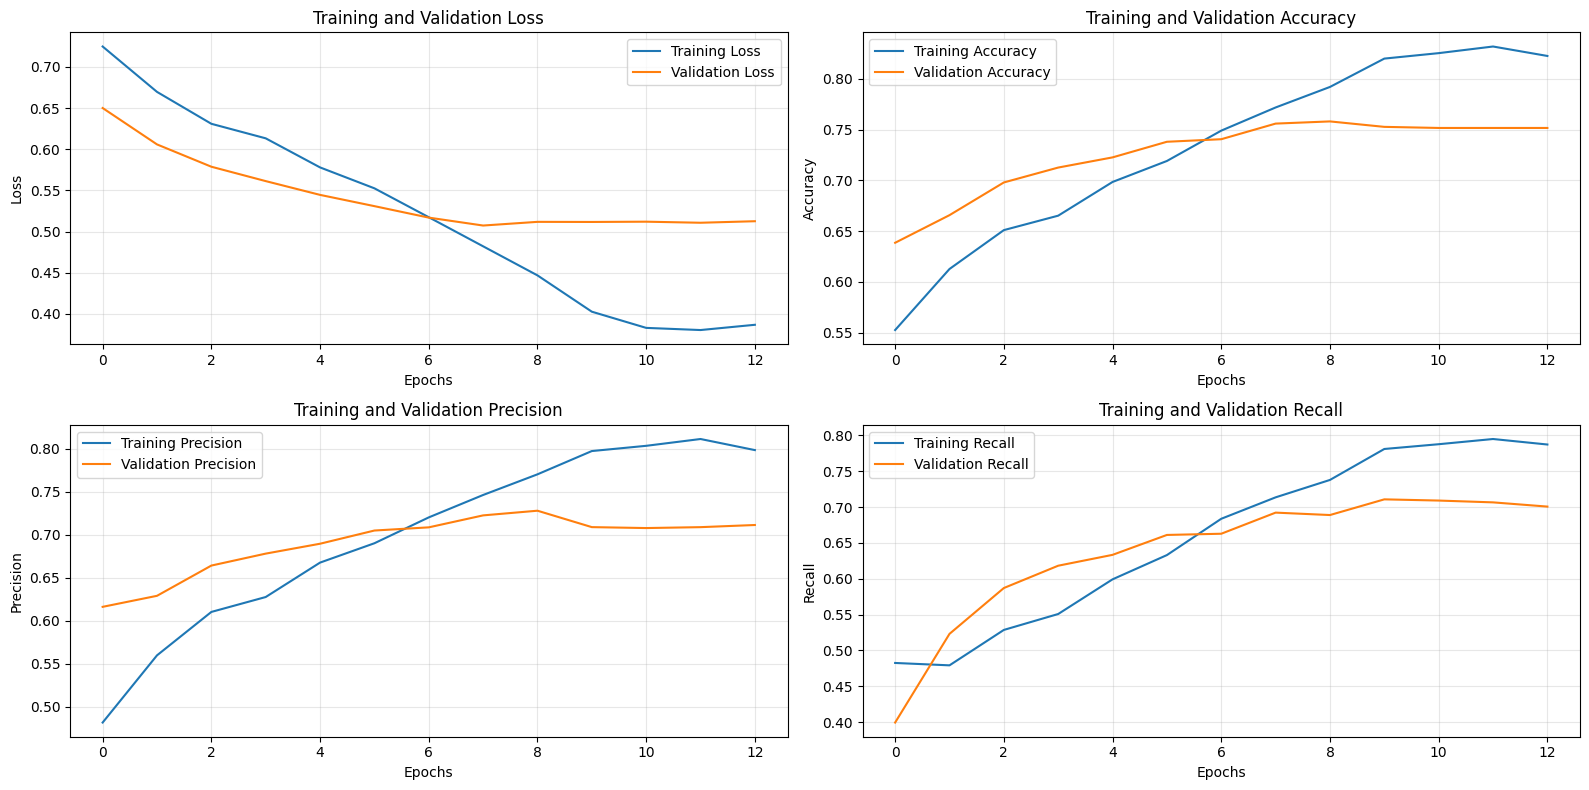


FINAL METRICS SUMMARY
Loss           : Train = 0.3869, Val = 0.5126
Binary_accuracy: Train = 0.8225, Val = 0.7516
Precision      : Train = 0.7986, Val = 0.7114
Recall         : Train = 0.7871, Val = 0.7006


In [7]:
with tf.device("/cpu:0"):
    print(history.history.keys())
    final_loss = history.history['loss'][-1]
    print(f"Final training loss: {final_loss}")
    
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(16, 8))
    plt.subplot(2, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    if 'binary_accuracy' in history.history:
        plt.subplot(2, 2, 2)
        plt.plot(history.history['binary_accuracy'], label='Training Accuracy')
        plt.plot(history.history['val_binary_accuracy'], label='Validation Accuracy')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.title('Training and Validation Accuracy')
        plt.legend()
        plt.grid(True, alpha=0.3)
    
    if 'precision' in history.history:
        plt.subplot(2, 2, 3)
        plt.plot(history.history['precision'], label='Training Precision')
        plt.plot(history.history['val_precision'], label='Validation Precision')
        plt.xlabel('Epochs')
        plt.ylabel('Precision')
        plt.title('Training and Validation Precision')
        plt.legend()
        plt.grid(True, alpha=0.3)
    
    if 'recall' in history.history:
        plt.subplot(2, 2, 4)
        plt.plot(history.history['recall'], label='Training Recall')
        plt.plot(history.history['val_recall'], label='Validation Recall')
        plt.xlabel('Epochs')
        plt.ylabel('Recall')
        plt.title('Training and Validation Recall')
        plt.legend()
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*50)
    print("FINAL METRICS SUMMARY")
    print("="*50)
    
    metrics_to_show = ['loss', 'binary_accuracy', 'precision', 'recall']
    for metric in metrics_to_show:
        if metric in history.history:
            train_val = history.history[metric][-1]
            val_key = f'val_{metric}'
            val_val = history.history[val_key][-1] if val_key in history.history else None
            
            print(f"{metric.capitalize():15}: Train = {train_val:.4f}", end="")
            if val_val is not None:
                print(f", Val = {val_val:.4f}")
            else:
                print()